# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint
### Assignment 2 Part-B: PEFT for Dialogue Summary

> **NOTE that** this Assignment is in 2 parts:
> - Part-A: Finetuning a Seq2Seq (T5) Model for Summarization
> - Part-B: PEFT for Dialogue Summary
>
>Only Part-B needs to be submitted for grading.

## Learning Objectives

At the end of the experiment, you will be able to:

* understand the working of a parameter efficinet finetuning method - LoRA
* fine tune a T5 model, `facebook/bart-large-cnn`, on the SAMSum dataset for summerization using LoRA
* push the finetuned LoRA adapter to HuggingFace model hub
* load the finetuned adapter from hub for inference

## Dataset Description

The **[SAMSum](https://huggingface.co/datasets/samsum) dataset** contains about 16k messenger-like conversations with summaries. Conversations were created and written down by linguists fluent in English. Linguists were asked to create conversations similar to those they write on a daily basis, reflecting the proportion of topics of their real-life messenger convesations. The style and register are diversified - conversations could be informal, semi-formal or formal, they may contain slang words, emoticons and typos. Then, **the conversations were annotated with summaries**. It was assumed that summaries should be a concise brief of what people talked about in the conversation in third person. The SAMSum dataset was prepared by Samsung R&D Institute Poland and is distributed for research purposes.

Data Splits:
- train: 14732
- val: 818
- test: 819

Data Fields:

- ***dialogue***: text of dialogue
- ***summary***: human written summary of the dialogue
- ***id***: unique id of an example

<br>

**Example:**

\{
> '**id**': '13818513',

>'**summary**': 'Amanda baked cookies and will bring Jerry some tomorrow.',

>'**dialogue**': "Amanda: I baked cookies. Do you want some?\r\nJerry: Sure!\r\nAmanda: I'll bring you tomorrow :-)"

\}

## Information

### **Parameter-Efficient Fine-Tuning (PEFT) methods**

Fine-tuning large pretrained models is often prohibitively costly due to their scale. Parameter-Efficient Fine-Tuning (PEFT) methods enable efficient adaptation of large pretrained models to various downstream applications by only fine-tuning a small number of (extra) model parameters instead of all the model's parameters. This significantly decreases the computational and storage costs. Recent state-of-the-art PEFT techniques achieve performance comparable to fully fine-tuned models.

PEFT is integrated with Transformers for easy model training and inference, and Accelerate for distributed training and inference for really big models.

[PEFT](https://github.com/huggingface/peft) is also a new open-source library from Hugging Face to enable efficient adaptation of pre-trained language models (PLMs) to various downstream applications ***without*** fine-tuning all the model's parameters.

PEFT currently includes techniques for:

- **LoRA:** Low-Rank Adaptation of Large Language Models
- **Prefix Tuning:** P-Tuning v2
- **P-Tuning**
- **Prompt Tuning**


### **LoRA**

It is a technique that accelerates the fine-tuning of large models while consuming less memory.

To make fine-tuning more efficient, LoRA's approach is to represent the weight updates with two smaller matrices (called update matrices) through low-rank decomposition.

A and B are update matrices in below figure.

<center>
<img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/peft/lora_diagram.png" width=900px>
</center>
<br>

- These new matrices can be trained to **adapt to the new data** while keeping the overall number of changes low.
- The original weight matrix **remains frozen** and doesn't receive any further adjustments.
- To produce the final results, both the original and the adapted weights are **combined**.

### Setup Steps:

In [1]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "2500856" #@param {type:"string"}

In [2]:
#@title Please enter your password (normally your phone number) to continue: { run: "auto", display-mode: "form" }
password = "9845104125" #@param {type:"string"}

##### After creating a copy of the notebook, follow the instructions below based on your batch:

* PG Batch: Run the below cell as it is.

* AC (Advanced) Batch: Follow the steps below to avoid execution errors.

1. Click on “Show Code” under the cell labeled:
    “Run this cell to complete the setup for this Notebook.”

2. Refer to the attached snippet and locate the red-highlighted section.

4. Add the following code snippet under the “Show Code” section, ensuring that the correct cohort ID is used in place of the example shown below:

           "batch": "IIITH-AC-AIML-26"  

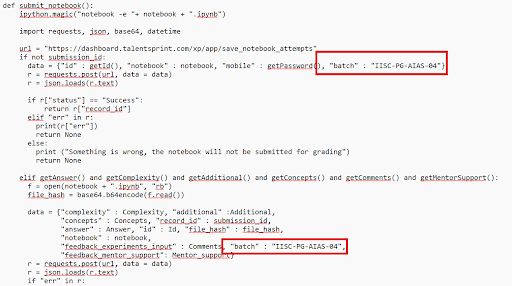

In [3]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython
import re
ipython = get_ipython()

notebook= "U4W20_68_Part-B_PEFT_for_Dialogue_Summary_C" #name of the notebook

def setup():
#  ipython.magic("sx pip3 install torch")
    from IPython.display import HTML, display
    ipython.magic("sx pip3 install torch")
    ipython.magic("sx pip3 install torchvision")
    ipython.magic("sx mkdir results")
    display(HTML('<script src="https://dashboard.talentsprint.com/aiml/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(),"batch": "IIITH-PG-AIML-26"}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print(r["err"])
        return None
      else:
        print ("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getWalkthrough() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook, "feedback_walkthrough":Walkthrough ,
              "feedback_experiments_input" : Comments,
              "feedback_inclass_mentor": Mentor_support,
              "batch": "IIITH-PG-AIML-26"}

      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


def getWalkthrough():
  try:
    if not Walkthrough:
      raise NameError
    else:
      return Walkthrough
  except NameError:
    print ("Please answer Walkthrough Question")
    return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")



Setup completed successfully


### Install required dependencies

In [4]:
!pip -q install transformers datasets evaluate transformers[torch]

# A dependecy required for loading SAMSum dataset
!pip -q install py7zr

!pip -q install peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 7.4 MB/s eta 0:00:00


### Import required packages

In [5]:
import os
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import TrainingArguments, Trainer

from peft import LoraConfig, get_peft_model, TaskType
from peft import PeftModel, PeftConfig

import warnings
warnings.filterwarnings('ignore')

### **Load Model & Tokenizer**

In [6]:
# Load model from HF Model Hub

"""
BART HAS 400M PARAMS: https://github.com/facebookresearch/fairseq/tree/main/examples/bart
Look into Model card - 400 Million parameters
"""

checkpoint = "facebook/bart-large-cnn"                # username/repo-name

# Load tokenizer
# YOUR CODE HERE
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# Load model
# YOUR CODE HERE
model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

### **Load Dataset**

In [7]:
import requests

url = 'https://arxiv.org/src/1911.12237v2/anc/corpus.7z'
file_path = '/content/corpus.7z'

print(f"Downloading {url} to {file_path}...")
response = requests.get(url, stream=True)
response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

with open(file_path, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download complete.")

Download complete.


In [8]:
!ls -l

total 2888
-rw-r--r-- 1 root root 2944100 Apr 19 05:41 corpus.7z
drwxr-xr-x 2 root root    4096 Apr 19 05:39 results
drwxr-xr-x 1 root root    4096 Apr 16 13:33 sample_data
-rw-r--r-- 1 root root     683 Apr 19 05:39 U4W20_68_Part-B_PEFT_for_Dialogue_Summary_C.ipynb


In [9]:
# extract the corpus.7z file into SAMSum folder
import py7zr

def extract_7z(archive_path, output_dir):
    """
    Extracts a .7z archive to the specified output directory.
    """
    # Validate file existence
    if not os.path.isfile(archive_path):
        print(f"Error: File '{archive_path}' does not exist.")
        return False

    # Validate file extension
    if not archive_path.lower().endswith(".7z"):
        print("Error: The file is not a .7z archive.")
        return False

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    try:
        with py7zr.SevenZipFile(archive_path, mode='r') as archive:
            archive.extractall(path=output_dir)
        print(f"Extraction completed successfully to: {output_dir}")
        return True
    except py7zr.Bad7zFile:
        print("Error: The archive is corrupted or not a valid .7z file.")
    except Exception as e:
        print(f"Unexpected error: {e}")
    return False


extract_7z('corpus.7z', 'SAMSum')



[corpus.7z]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of corpus.7z or
        corpus.7z.zip, and cannot find corpus.7z.ZIP, period.
Extraction completed successfully to: SAMSum


True

In [10]:
# Load SAMSum dataset
# YOUR CODE HERE to load "samsum" dataset
dataset = load_dataset('SAMSum')
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'summary', 'dialogue'],
        num_rows: 14732
    })
    validation: Dataset({
        features: ['id', 'summary', 'dialogue'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'summary', 'dialogue'],
        num_rows: 819
    })
})

### **Prepare the Dataset**

In [11]:
# Define function to prepare dataset
block_size = 256
def tokenize_inputs(example):

    # YOUR CODE HERE
    start_prompt = "Summarize the following conversation.\n\n"
    end_prompt = "\n\nSummary: "
    prompt = [start_prompt + dialogue + end_prompt for dialogue in example['dialogue']]
    # YOUR CODE HERE to apply tokenizer on prompt
    #print(tokenizer(example["dialogue"], padding='max_length', truncation=True, max_length=block_size, return_tensors='pt'))
    example['input_ids'] = tokenizer(example["dialogue"], padding='max_length', truncation=True, max_length=block_size, return_tensors='pt')['input_ids']
    # YOUR CODE HERE to apply tokenizer on 'summary'
    example['labels'] = tokenizer(example["summary"], padding='max_length', truncation=True, max_length=block_size, return_tensors='pt')['attention_mask']

    return example

In [12]:
# Prepare dataset
# The line `tokenizer.pad_token = tokenizer.eos_token` is removed as BART already has a distinct pad token,
# and setting it to `eos_token` can cause issues with generation.
tokenized_datasets = dataset.map(tokenize_inputs, batched=True)       # using batched=True for Fast tokenizer implementation
print(f"Before: {tokenized_datasets}")
# Remove columns/keys that are not needed further
# YOUR CODE HERE
tokenized_datasets = tokenized_datasets.remove_columns(['id', 'dialogue', 'summary'])
tokenized_datasets

Map:   0%|          | 0/14732 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Before: DatasetDict({
    train: Dataset({
        features: ['id', 'summary', 'dialogue', 'input_ids', 'labels'],
        num_rows: 14732
    })
    validation: Dataset({
        features: ['id', 'summary', 'dialogue', 'input_ids', 'labels'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'summary', 'dialogue', 'input_ids', 'labels'],
        num_rows: 819
    })
})


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 14732
    })
    validation: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 818
    })
    test: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 819
    })
})

In [13]:
# Shortening the data: Just picking row index divisible by 100
# For learning purpose! It will reduce the compute resource requirement and training time

# YOUR CODE HERE
tokenized_datasets = tokenized_datasets.filter(lambda example, index: index % 100 == 0, with_indices=True)

Filter:   0%|          | 0/14732 [00:00<?, ? examples/s]

Filter:   0%|          | 0/818 [00:00<?, ? examples/s]

Filter:   0%|          | 0/819 [00:00<?, ? examples/s]

In [14]:
print(tokenized_datasets['train'].shape)
print(tokenized_datasets['validation'].shape)
print(tokenized_datasets['test'].shape)

(148, 2)
(9, 2)
(9, 2)


### **Create PEFT Model using LoRA**

To fine-tune a model using LoRA, you need to:

- Instantiate a base model, here it is `facebook/bart-large-cnn`
- Create a configuration (`LoraConfig`) where you define LoRA-specific parameters
- Wrap the base model with `get_peft_model()` to get a trainable `PeftModel`
- Train the `PeftModel` as you normally would train the base model

In [15]:
from peft import LoraConfig, get_peft_model, TaskType

# LoRA-specific parameters
lora_config = LoraConfig(
    r=32,                       # 8, 16, 32    # the rank of the update matrices
    lora_alpha=32,                             # LoRA scaling factor
    lora_dropout=0.05,
    bias='none',                               # specifies if the bias parameters should be trained
    task_type=TaskType.SEQ_2_SEQ_LM,           # telling lora that this is a sq2seq modeling task
)

In [16]:
# Trainable PEFTModel
peft_model = get_peft_model(model, peft_config=lora_config)

### **Train PEFT Model**

In [17]:
from transformers import TrainingArguments, Trainer
model_output_path = 'PEFT_LORA_model'
# YOUR CODE HERE for TrainingArguments() object
peft_training_args = TrainingArguments(
      output_dir = model_output_path,
      # overwrite_output_dir = True, # Removed this line
      num_train_epochs = 5,
      per_device_train_batch_size = 4,
      per_device_eval_batch_size = 4,
      save_steps = 1_00,
      save_total_limit = 2,
      logging_dir = './logs'

)


# Create a Data collator object
#data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False, return_tensors="pt")
#Not using a data collator

# YOUR CODE HERE for Trainer() object

peft_trainer = Trainer(model = peft_model,
                  args= peft_training_args,
                  train_dataset = tokenized_datasets['train'],
                  eval_dataset = tokenized_datasets['validation'])

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
# Number of trainable parameters
peft_model.print_trainable_parameters()

trainable params: 4,718,592 || all params: 411,009,024 || trainable%: 1.1481


From above we can see, here we are only training 1.14% of the parameters of the model.

In [19]:
# Disabling Weights and Biases logging
import os
os.environ["WANDB_DISABLED"] = "true"

In [20]:
# Training
peft_trainer.train()

Step,Training Loss


TrainOutput(global_step=185, training_loss=5.560234770903716, metrics={'train_runtime': 110.0374, 'train_samples_per_second': 6.725, 'train_steps_per_second': 1.681, 'total_flos': 406277691801600.0, 'train_loss': 5.560234770903716, 'epoch': 5.0})

### **Save PEFT Adapter**

**Push your Peft adapter to Hugging Face Model Hub**

In [23]:
# Login to HuggingFace
# Run, and paste your HF Access token when prompted
from huggingface_hub import notebook_login
notebook_login()

In [22]:
# Push peft adapter to Hub
my_peft_repo = "PEFT_Example"
model.push_to_hub(repo_id= my_peft_repo, commit_message= "Upload fine-tuned model")
tokenizer.push_to_hub(repo_id= my_peft_repo, commit_message= "Upload tokenizer used")



# YOUR CODE HERE to push peft_model to my_peft_repo

HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-69e46bbb-6325655f266cf0631c142a03;91701843-3317-4d4c-8415-da466ccca433)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

Access your pushed adapter at `https://huggingface.co/[YOUR-USER-NAME]/[YOUR-MODEL-REPO-NAME]/tree/main`

### **Reload & Test**

**Test your LoRA finetuned model downloaded from HF Model Hub**

In [24]:
#username = "sumanthk"      # change it to your HuggingFace username
username = "tarantripathi"      # change it to your HuggingFace username

#checkpoint = username + '/PEFT_Partb'  # change it to your Repo name
checkpoint = username + '/PEFT_Example'  # change it to your Repo name

# YOUR CODE HERE to load Seq2SeqLM with 'checkpoint'
loaded_model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)

# YOUR CODE HERE to load tokenizer with 'checkpoint'
loaded_tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.64G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/368 [00:00<?, ?it/s]

BartForConditionalGeneration LOAD REPORT from: tarantripathi/PEFT_Example
Key                                                                     | Status     | 
------------------------------------------------------------------------+------------+-
model.decoder.layers.{0...11}.encoder_attn.q_proj.lora_A.default.weight | UNEXPECTED | 
model.decoder.layers.{0...11}.self_attn.v_proj.lora_A.default.weight    | UNEXPECTED | 
model.decoder.layers.{0...11}.self_attn.q_proj.lora_B.default.weight    | UNEXPECTED | 
model.decoder.layers.{0...11}.encoder_attn.v_proj.base_layer.bias       | UNEXPECTED | 
model.decoder.layers.{0...11}.encoder_attn.q_proj.base_layer.weight     | UNEXPECTED | 
model.decoder.layers.{0...11}.self_attn.v_proj.base_layer.bias          | UNEXPECTED | 
model.decoder.layers.{0...11}.encoder_attn.q_proj.base_layer.bias       | UNEXPECTED | 
model.decoder.layers.{0...11}.encoder_attn.v_proj.lora_A.default.weight | UNEXPECTED | 
model.decoder.layers.{0...11}.self_attn.q_proj

generation_config.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/386 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [31]:
def generate_summary(input, llm):
    """Prepare prompt  -->  tokenize -->  generate output using LLM  -->  detokenize output"""

    input_prompt = f"""
                    Summarize the following conversation.

                    {input}

                    Summary:
                    """

    # YOUR CODE HERE for tokenizer()
    input_ids = tokenizer.encode(input_prompt, return_tensors="pt")      # 'pt' for returning pytorch tensor

    # Check the device of the model
    device = next(llm.parameters()).device
    input_ids = input_ids.to(device)

    # Create the attention mask and pad token id
    attention_mask = torch.ones_like(input_ids)
    # Use model's configured pad_token_id for generation, with tokenizer's pad_token_id as fallback
    pad_token_id_for_gen = llm.config.pad_token_id if llm.config.pad_token_id is not None else tokenizer.pad_token_id

    # YOUR CODE HERE
    tokenized_output = llm.generate(
        input_ids,
        max_length=100,
        num_return_sequences=1,
        attention_mask=attention_mask,
        pad_token_id=pad_token_id_for_gen
    )

    output = tokenizer.decode(tokenized_output[0], skip_special_tokens=True)
    return output

In [32]:
sample = dataset['test'][0]['dialogue']
label = dataset['test'][0]['summary']

output = generate_summary(sample, llm=loaded_model)

print("Sample")
print(sample)
print("-------------------")
print("Summary:")
print(output)
print("Ground Truth Summary:")
print(label)

Sample
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye
-------------------
Summary:
26-toTo PO" P" PU" PP"" (""" trib"" U"" Mot" ( (" ( Mot (" Mot ( ( Mot" Mot Mot Mot"" top ( ( ( Autom ( Mot Mot ( Mot Autom (" Autom ( ( top ( MotU"" Autom Mot" Autom" ( Autom Mot ( Autom" MotATED ( Mot27 ( ( - ( (ATED ("ATED ( (27" (
Ground Truth Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.


### References:

1. [LoRA](https://huggingface.co/docs/peft/main/en/conceptual_guides/lora)
2. [Quicktour](https://huggingface.co/docs/peft/en/quicktour)
3. [Efficient Large Language Model training with LoRA and Hugging Face](https://www.philschmid.de/fine-tune-flan-t5-peft)

### Please answer the questions below to complete the experiment:




In [24]:
#@title Select the False statement w.r.t LoRA: { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "During inference, only the original weight matrix is used to produce final results" #@param ["", "It is a technique that accelerates the fine-tuning of large models while consuming less memory", "During training, the original weight matrix remains frozen and doesn't receive any further adjustments", "During inference, only the original weight matrix is used to produce final results", "None of the above"]

In [25]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "Good and Challenging for me" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [26]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "hugging face interface using training arguments. overwrite param was used in last workbook, but here it is removed, a bit struggle there. downloading SAMSum needed a bit of searhingg" #@param {type:"string"}


In [27]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "Yes" #@param ["","Yes", "No"]


In [28]:
#@title  Experiment walkthrough video? { run: "auto", vertical-output: true, display-mode: "form" }
Walkthrough = "Didn't use" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [29]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [30]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [31]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

Your submission is successful.
Ref Id: 13982
Date of submission:  19 Apr 2026
Time of submission:  09:42:36
View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions
